# ASSIGNMENT 10: SUPPORT VECTOR MACHINE

In [9]:
# Numerical operations
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [10]:
# Load the dataset
df = pd.read_csv("Pharma_Industry.csv")

# Display first 5 rows
df.head()


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [12]:
df.describe()


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [13]:
# Check if there are any missing values
df.isnull().sum()


Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

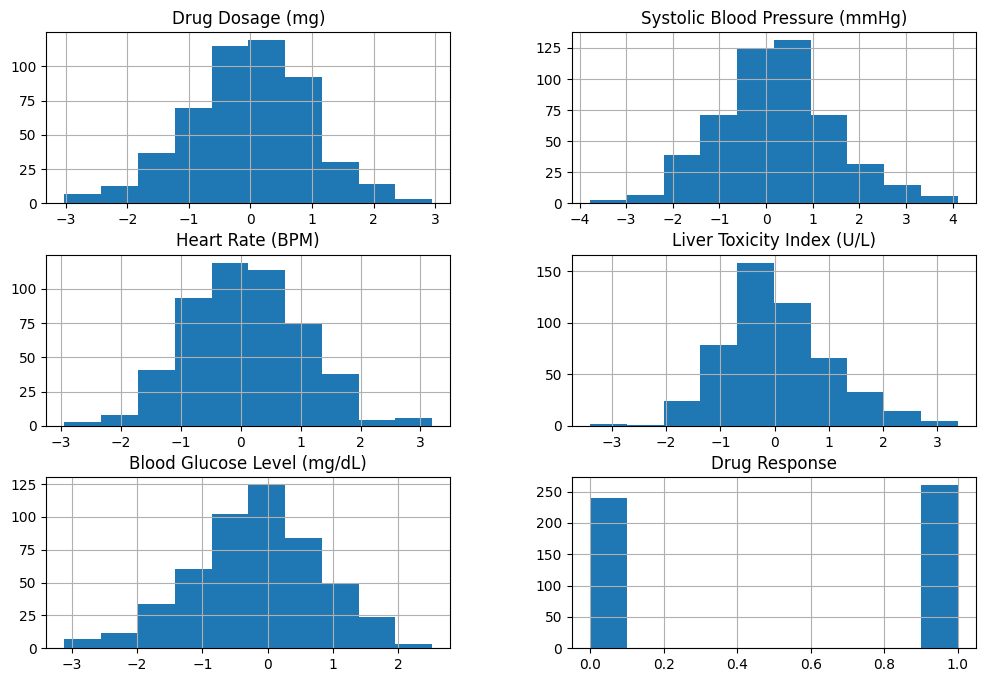

In [14]:
# Plot histograms for all features
df.hist(figsize=(12, 8))
plt.show()


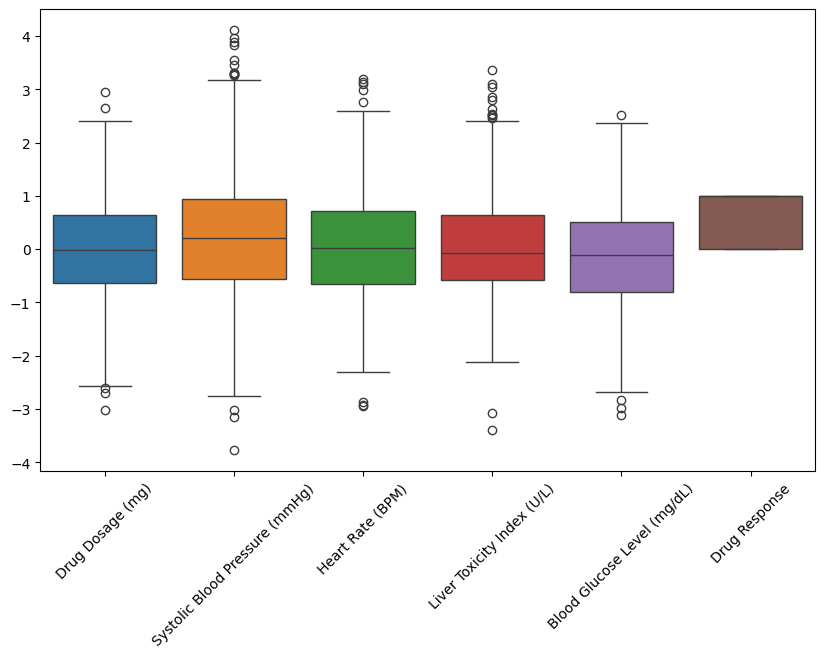

In [15]:
# Box plot to identify outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()


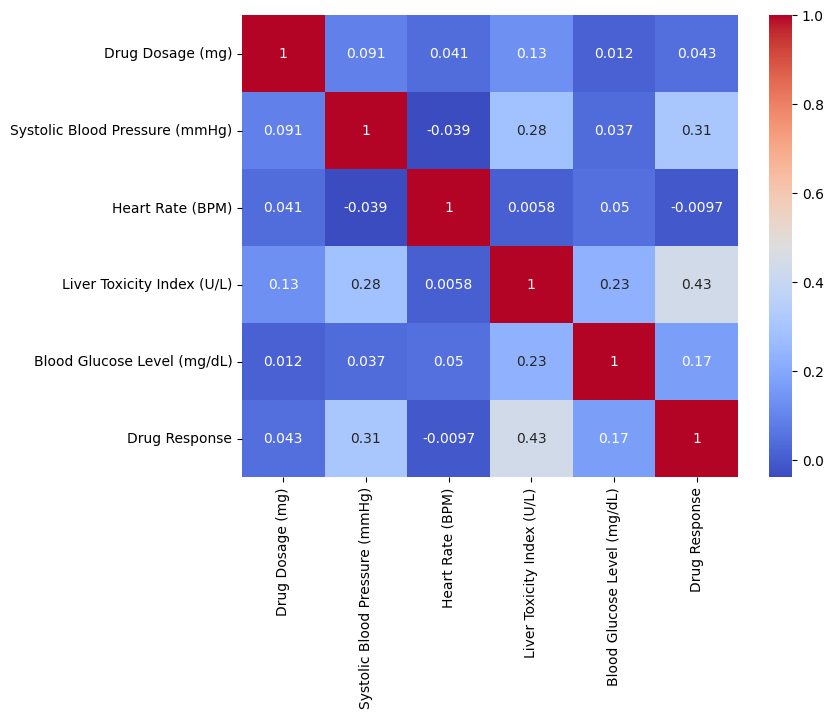

In [16]:
# Heatmap to visualize correlation between features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


In [17]:
# DATA PREPROCESSING
# X contains all features (independent variables)
X = df.drop("Drug Response", axis=1)

# y contains the target variable
y = df["Drug Response"]


In [18]:
# Split data into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


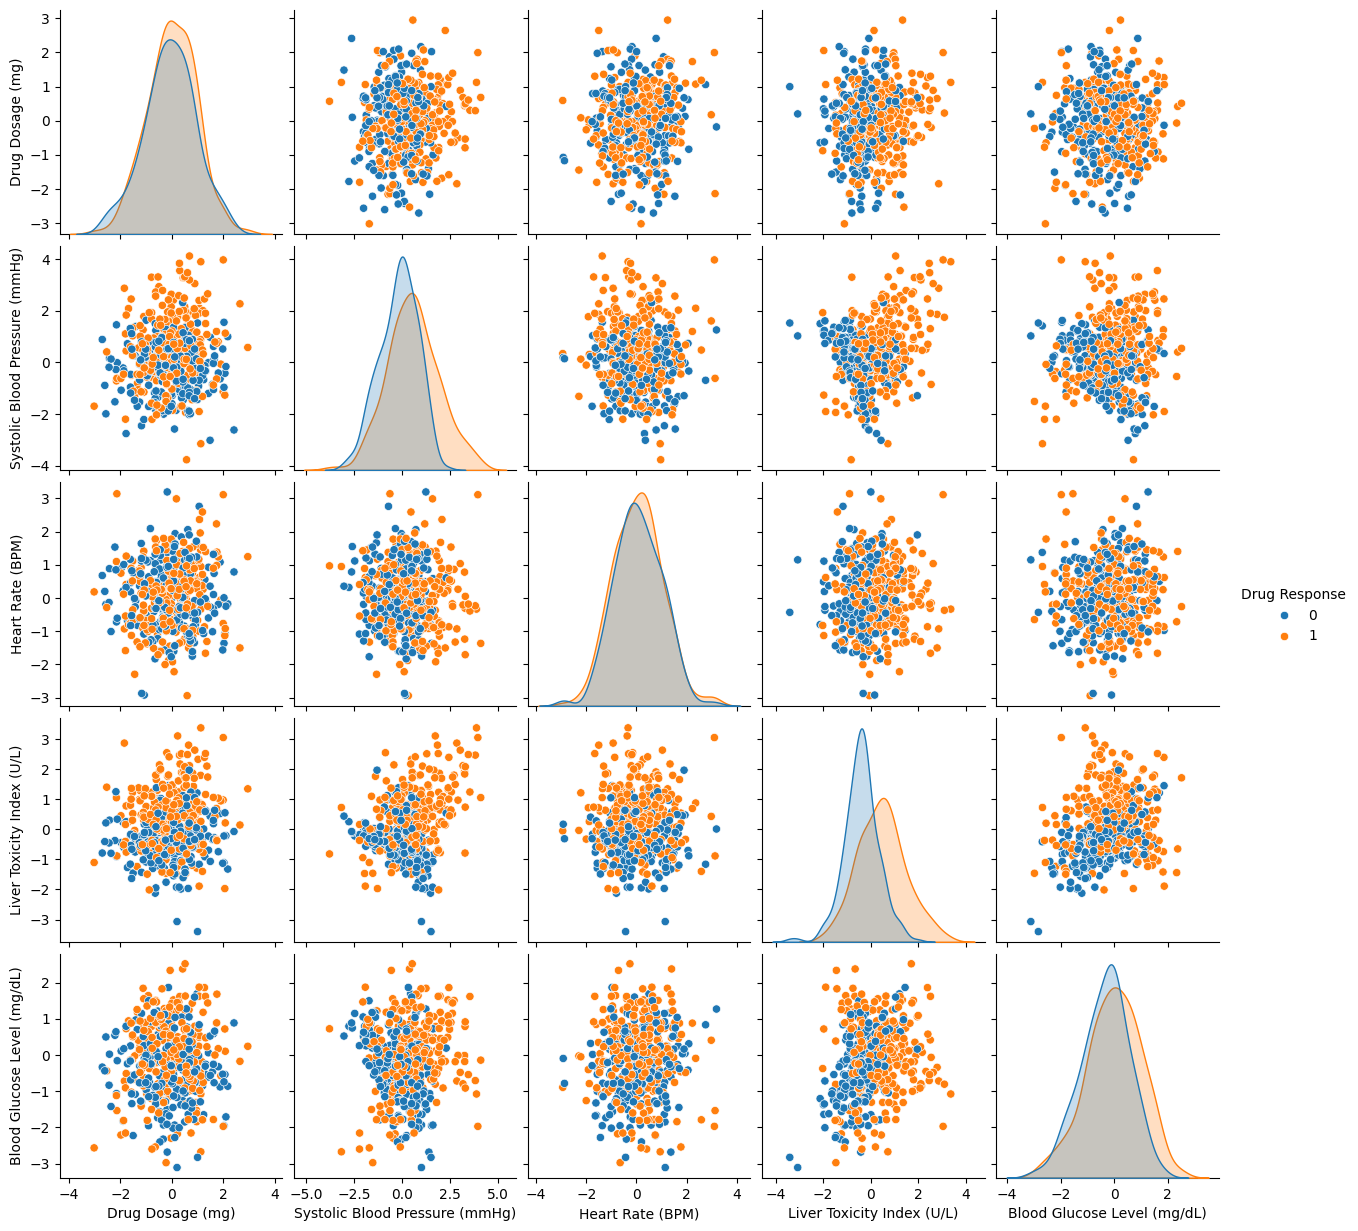

In [19]:
# DATA VISUALISATION
# Pairwise relationship visualization
sns.pairplot(df, hue="Drug Response")
plt.show()


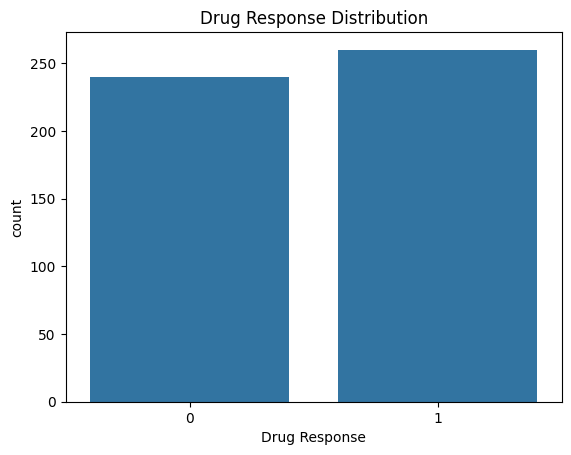

In [20]:
# Count plot to check class balance
sns.countplot(x=y)
plt.title("Drug Response Distribution")
plt.show()


In [21]:
# IMPLEMENTING SVM
# Create SVM model with linear kernel
svm_model = SVC(kernel="linear")
# Train SVM using training data
svm_model.fit(X_train, y_train)
# Predict drug response on test data
y_pred = svm_model.predict(X_test)


In [22]:
# MODEL EVALUATION
# Accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7066666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.80      0.71        69
           1       0.78      0.63      0.70        81

    accuracy                           0.71       150
   macro avg       0.72      0.71      0.71       150
weighted avg       0.72      0.71      0.71       150



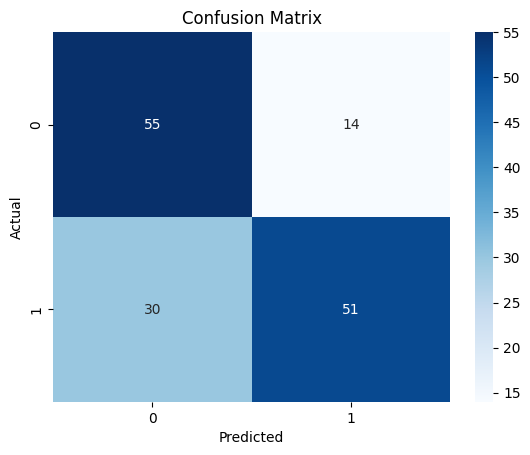

In [23]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


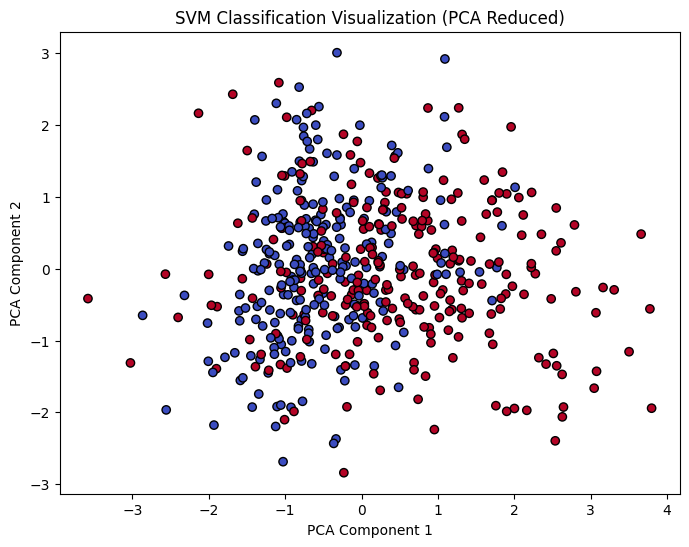

In [ ]:

# VISUALIZATION OF SVM RESULTS


# Import all required libraries for this step
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Separate features and target
X = df.drop("Drug Response", axis=1) 
y = df["Drug Response"]              

# Standardize the feature data (IMPORTANT for PCA & SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce feature space to 2 dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Train SVM model on PCA-reduced data
svm_vis = SVC(kernel="linear")
svm_vis.fit(X_pca, y)

# Scatter plot of classification result
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="coolwarm",
    edgecolors="black"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("SVM Classification Visualization (PCA Reduced)")
plt.show()


In [27]:
# HYPERPARAMETER TUNING 
# Define hyperparameter grid
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"]
}

# Grid search for best parameters
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [28]:
# Compare different SVM kernels
kernels = ["linear", "rbf", "poly"]

for kernel in kernels:
    model = SVC(kernel=kernel)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{kernel.upper()} Kernel Accuracy:", accuracy_score(y_test, preds))


LINEAR Kernel Accuracy: 0.7066666666666667
RBF Kernel Accuracy: 0.7933333333333333
POLY Kernel Accuracy: 0.72
